In [88]:
!python --version

Python 3.9.25


https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/07_food_vision_milestone_project_1.ipynb

# Milestone Project 1: Food Vision Big

See the annotated version of this notebook on github link above

## Check GPU

Google colab offers free GPUS but most aren't that great compared to my 4080 super so using that instead also running this on jupyter labs and not colab.

In order to use mixed-precision training you need access to a GPU which has a certain amount of compute cabability which is currently 7.0 + to see good results. 

List here of compute capability: https://developer.nvidia.com/cuda/gpus docs here for mixed precision: https://www.tensorflow.org/guide/mixed_precision

In [89]:
# List GPU info cuda version, driver version etc.
!nvidia-smi

Sun Mar  8 18:51:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    Off |   00000000:09:00.0  On |                  N/A |
| 31%   29C    P2             45W /  320W |   14268MiB /  16376MiB |     16%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [90]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision


## Get helper functions

In past modules, we've created a bunch of helper functions to do small tasks required for our notebooks.

Rather than rewrite all of these we can import a script and load them in from there.

The script we have available will be on github: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/helper_functions.py can use !wget to download this already downloaded on my machine.

In [91]:
!python --version
import sys
print(sys.path)
import os
print(os.listdir())
# import series of helper functions
from helper_functions import create_tensorboard_callback,plot_loss_curves,compare_historys

Python 3.9.25
['/home/sl0th/.pyenv/versions/3.9.25/lib/python39.zip', '/home/sl0th/.pyenv/versions/3.9.25/lib/python3.9', '/home/sl0th/.pyenv/versions/3.9.25/lib/python3.9/lib-dynload', '', '/home/sl0th/.pyenv/versions/3.9.25/lib/python3.9/site-packages']
['06_transfer_learning_in_tensorflow_part_3_sdcaling_up_video.ipynb', '03-steak.jpeg', '03_introduction_to_computer_vision_with_tensorflow.ipynb', 'README.md', 'confusion_matrix.png', 'model_checkpoints', '.gitignore', 'Exercises', '03-sushi.jpeg', '03-pizza-dad.jpeg', 'transfer learning', 'helper_functions.py', '06_101_food_class_10_percent_saved_big_dog_model.zip', '03-pizza-dad.jpeg.1', 'transfer_learning', '05_transfer_learning_in_tensorflow_part_2_fine_tuning.ipynb', 'training_logs', '03-hamburger.jpeg', '__MACOSX', '01_neural_network_regression_with_tensorflow.ipynb', '__pycache__', 'tensorflow_hub', '10_food_classes_all_data', '02_Neural_Network_Classification_with_Tensorflow.ipynb', 'custom_food_images', 'custom_food_images.zi

## Use Tensorflow Datasets to download data

To get an overview of tensorflow datasets TFDS read the guide here https://www.tensorflow.org/datasets/overview

In [92]:
# Get tensorflow datasets
import tensorflow_datasets as tfds

In [93]:
# List all available datasets
datasets_list = tfds.list_builders() # Get all available datasets in tfds
print("food101" in datasets_list) # is food 101 here?  Spoiler yes

True


In [94]:
import logging

# Set tfds/tensorflow logging to only show fatal errors
tf.get_logger().setLevel(logging.FATAL)
tfds.disable_progress_bar()


# Load in food 101 dataset
(train_data, test_data), ds_info = tfds.load(name="food101",
                                                 split=["train","validation"],
                                                 shuffle_files=True, 
                                                 as_supervised=True, #data returned in tuple
                                                 with_info=True)

## Exploring the Food101 data from TensorFlow Datasets

To become one with our data, we want to find:

* Class names
* The shape of our input data(image tensors)
* The data type of our input data
* What the labels look like (e.g. are they one hot-encoded or are they label encoded)
* Do the labels match up with the class_names?

In [95]:
# Features of food 101 from tfds
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [96]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [97]:
# Take one sample of our training data
train_one_sample = train_data.take(1) #samples are in format (image_tensor,label)

In [98]:
# What does one sample of our training data look like?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [99]:
# Output info about our training sample
for image, label in train_one_sample:
    print(f"""
        Image shape: {image.shape},
        Image datatype: {image.dtype},
        Target class from Food101 (tensor form): {label},
        Class name (str form): {class_names[label.numpy()]}
    """)


        Image shape: (512, 512, 3),
        Image datatype: <dtype: 'uint8'>,
        Target class from Food101 (tensor form): 8,
        Class name (str form): bread_pudding
    


2026-03-08 18:51:24.529925: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [100]:
# What does our image tensor from TFDS's Food 101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[18,  6,  8],
        [18,  6,  8],
        [18,  6,  8],
        ...,
        [30, 15, 22],
        [29, 14, 21],
        [26, 11, 18]],

       [[22, 10, 12],
        [21,  9, 11],
        [20,  8, 10],
        ...,
        [35, 20, 27],
        [31, 16, 23],
        [26, 11, 18]],

       [[23, 13, 14],
        [21, 11, 12],
        [19,  9, 10],
        ...,
        [39, 26, 33],
        [36, 21, 28],
        [30, 15, 22]],

       ...,

       [[15,  4,  8],
        [15,  4,  8],
        [14,  5, 10],
        ...,
        [41,  9, 10],
        [39,  7,  8],
        [36,  4,  5]],

       [[16,  5,  9],
        [16,  5,  9],
        [16,  5, 11],
        ...,
        [42, 12, 12],
        [39,  9,  9],
        [35,  5,  5]],

       [[15,  4,  8],
        [15,  4,  8],
        [16,  5, 11],
        ...,
        [41, 11, 11],
        [39,  9,  9],
        [35,  5,  5]]], dtype=uint8)>

In [101]:
# What are min and max of our image tensor?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image from TFDS

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

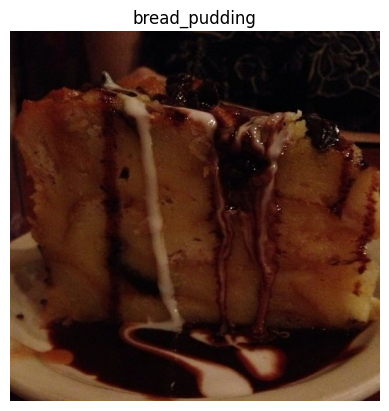

In [102]:
from matplotlib.pyplot import imshow,title, axis

imshow(image)
title(class_names[label.numpy()]) # Add title to verify the label is associated with right image
axis(False)

## Create preprocessing functions for our data

Neural networks perform best when data is standardised eg: batched, normalized, etc

However, not all data even those from TFDS come preprocessed.

In order to get data ready for a nerual network, you often have to preprocess the data by writing preprocessing functions and map it to your data.

What we know about our data:
* In `uint8` datatype
* It's comprised of all different size tensors (different sized images)
* Not scaled (the pixel values are between 0 and 255)

What we know models like:
* Data in `float32` or `float16` datatypes or in case of mixed precision combination of too
* For batches Tensorflow likes all of the tensors within a batch to be in the same size
* Scaled (values between 0 and 1) also called normalized tensors generally perform better

With these points in mind, we've got a few things we can tackle with a preprocessing function.

Since we're going to be using an EfficientNetBX pretrained model from tf.keras.applications we don't need to rescale our data these architectures have recaling built in.

This means our functions needs to:
1. reshape our images to all same size
2. Convert the dtype of all our image tensors from `uint8` to `float32`

In [103]:
# Make a function for preprocessing images
def preprocess_image(image,label,img_shape=224):
    """
    Converts image data type from 'uint8' to 'float32' and reshapes image to [img_shape,img_shape,color_channels]
    """
    image = tf.image.resize(image,[img_shape,img_shape]) #reshape target image
    #image /= 255 #scale image vals(not required when using EfficientNetBX models from tf.keras.applications
    return tf.cast(image,tf.float32), label #return tuple of (float32_image,label) tuple
    

In [104]:
# Preprocess a single sample image and check the output
preprocessed_img = preprocess_image(image,label)[0]
print(f"Image before preprocessing:\n {image[:2]}..., \nShape:{image.shape},\nDatatype:{image.dtype}")
print(f"Image after preprocessing:\n{preprocessed_img[:2]}...,\nShape:{preprocessed_img.shape},\nDatatype:{preprocessed_img.dtype}")

Image before preprocessing:
 [[[18  6  8]
  [18  6  8]
  [18  6  8]
  ...
  [30 15 22]
  [29 14 21]
  [26 11 18]]

 [[22 10 12]
  [21  9 11]
  [20  8 10]
  ...
  [35 20 27]
  [31 16 23]
  [26 11 18]]]..., 
Shape:(512, 512, 3),
Datatype:<dtype: 'uint8'>
Image after preprocessing:
[[[20.158163   8.158163  10.158163 ]
  [18.42347    7.6173472  9.020408 ]
  [15.010203   6.423469   9.285714 ]
  ...
  [26.285824  15.714351  23.07156  ]
  [31.091867  17.285728  24.285728 ]
  [28.754953  13.754952  20.754953 ]]

 [[18.92857    8.928571   9.928571 ]
  [16.214285   7.0765305  8.07653  ]
  [14.739796   8.571429  10.627552 ]
  ...
  [26.444029  15.872557  21.658293 ]
  [39.86226   26.862259  33.86226  ]
  [39.49479   24.494787  31.494787 ]]]...,
Shape:(224, 224, 3),
Datatype:<dtype: 'float32'>


## Batch and prepare datasets

We're now going to make our data input pipeline run really fast.

For more resources on this, I'd highly recommend going through the following guide https://www.tensorflow.org/guide/data_performance

In [105]:
# Map preprocessing function to training data(and parallelize)
train_data = train_data.map(map_func=preprocess_image,num_parallel_calls=tf.data.AUTOTUNE)
# Shuffle train_data and turn it into batches and prefetch it (load faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)
# Map preprocessing function to test data
test_data = test_data.map(map_func=preprocess_image,num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE).cache()
test_data = test_data.prefetch(tf.data.AUTOTUNE)

In [106]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

> "Hey Tensorflow, map this preprocessing function (`preprocess_img`) across our training dataset, then shuffle a number of elements and then batch them together and finally make sure you prepare new batches(prefetch) whilst the model is looking through(finding patterns) in current batch"

## Create modelling callbacks

We're going to create a couple of callbacks to help us while our model trains:
* Tensorboard callback to log training results (so we can visualize them later if need be)
* ModelCheckpoint callback to save our model's progress after feature extraction

In [107]:
# Create tensorboard callback (import from helper_functions.py)
from helper_functions import create_tensorboard_callback

# create model checkpoint callback to save a model's progress during training
checkpoint_path = "model_checkpoints/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor='val_acc',
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      verbose=0 # don't print anything whether or not model is being saved
                                                     )

## Setup mixed precision training
First and foremost, for a deeper understanding of mixed precision training checkout the Tensorflow guide for mixed precision: https://www.tensorflow.org/guide/mixed_precision

Mixed precision uses a combination of `float32` and `float16` to speed up model performance

In [108]:
# Turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy(policy="mixed_float16") # Set global data policy to mixed precision

In [109]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

## Build feature extraction model

In [110]:
from tensorflow.keras import layers, preprocessing

# Create base model
input_shape = (224,224,3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Create functional model
inputs = layers.Input(shape=input_shape, name="input_layer")
# Note: efficient net bx models have rescaling built in but if we use model that doesn't we can have layer like below
# x = preprocessing.Rescaling(1./255)(x)
x = base_model(inputs, training=False) # Make sure layers which should be in inference(non-trained) mode only stay that way
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(len(class_names))(x)
# Make sure outpus are in shape 32
outputs = layers.Activation("softmax", dtype=tf.float32,name="softmax_float32")(x)
model = tf.keras.Model(inputs,outputs)

# Compile model - note categorical crossentropy is for one-hot-encoded labels
model.compile(loss="sparse_categorical_crossentropy",
             optimizer=tf.keras.optimizers.Adam(),
             metrics=["accuracy"]);

In [111]:
len(class_names)

101

In [112]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Checking layer dtype policies (are we using mixed precision?)

In [113]:
for layer in model.layers:
    print("name of layer: ", layer.name, "\ndata type of layer: ", 
          layer.dtype, "\ntrainable? ", layer.trainable, "\npolicy ", layer.dtype_policy, "\n")

name of layer:  input_layer 
data type of layer:  float32 
trainable?  True 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  efficientnetb0 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  global_average_pooling2d_3 
data type of layer:  float32 
trainable?  True 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  dense_3 
data type of layer:  float32 
trainable?  True 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  softmax_float32 
data type of layer:  float32 
trainable?  True 
policy  <DTypePolicy "float32"> 



Going through the above we see:
* `layer.name`: the human readable name of a particular layer
* `layer.trainable`: is the layer trainable or not? (if `False` the weights are frozen)
* `layer.dtype`: the data type a layer stores its variables in
* `layer.dtype_policy`: the data type policy a layer computes on its variables with

In [114]:
# Check dtype_policy attributes of layers in the base model
for layer in model.layers[1].layers[:20]:
    print("name of layer: ", layer.name, "\ndata type of layer: ", 
    layer.dtype, "\ntrainable? ", layer.trainable, "\npolicy ", layer.dtype_policy, "\n")

name of layer:  input_layer_3 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  rescaling_6 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  normalization_3 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  rescaling_7 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  stem_conv_pad 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  stem_conv 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  stem_bn 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  stem_activation 
data type of layer:  float32 
trainable?  False 
policy  <DTypePolicy "mixed_float16"> 

name of layer:  block1a_dwconv 
data type of layer

In [115]:
mixed_precision.global_policy()

<DTypePolicy "mixed_float16">

## Fit the feature extraction model

If our goal is to fine tune a pretrained model, the general order of doing things is:
1. Build a feature extraction model (train a couple output layers with base layers frozen)
2. Fine-tune some of the frozen layers

In [116]:
# fit feature extraction model with callbacks
history_101_food_classes_feature_extract = model.fit(train_data,                                               
                                                     epochs=3,
                                                     steps_per_epoch=len(train_data),
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)),
                                                     callbacks=[create_tensorboard_callback(dir_name="training_logs",
                                                                                           experiment_name="efficientnetb0_101_classes_all_data_feature_extract"),
                                                     model_checkpoint])

Saving TensorBoard log files to: training_logs/efficientnetb0_101_classes_all_data_feature_extract/20260308-185125
Epoch 1/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4762 - loss: 2.2864

/home/sl0th/.pyenv/versions/3.9.25/lib/python3.9/site-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 87s 28ms/step - accuracy: 0.4762 - loss: 2.2862 - val_accuracy: 0.6957 - val_loss: 1.1270
Epoch 2/3
2366/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6673 - loss: 1.2884

2026-03-08 18:53:35.713925: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.6673 - loss: 1.2883 - val_accuracy: 0.7177 - val_loss: 1.0379
Epoch 3/3
2367/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7058 - loss: 1.1301

2026-03-08 18:54:19.309906: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 44s 18ms/step - accuracy: 0.7058 - loss: 1.1301 - val_accuracy: 0.7309 - val_loss: 0.9951


2026-03-08 18:54:21.289450: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In [117]:
# Evaluate model on whole test dataset
results_feature_extract_model = model.evaluate(test_data)
results_feature_extract_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.7293 - loss: 0.9985


## Off to you...
We've covered a lot of ground so far but given this is milestone project it's time for personal challgenge.

The challenge is to complete the template version of 07 to obtain a computer vision model(building off the one we've built in this notebook) to beat the food101 paper accuracy of 77.4%

Time to create Food Learning Big!

# Exercise:

1. Build and train feature extraction model - done
2. Beat deep food paper accuracy of 77.4%
3. Evaluate model results on tensorboard
4. Evaluating the model results by making and plotting predictions on images